In [1]:
import pandas as pd
import numpy as np
import re

# 1. Load the Dataset
df = pd.read_csv('CarsDatasets.csv')

# ---------------------------------------------------------
# 2. Advanced Preprocessing: Numeric Extraction
# ---------------------------------------------------------

def clean_and_parse_numeric(text):
    """
    Extracts numbers from strings like '$12,000-$15,000', '70-85 hp', or '2.5 sec'.
    Returns the average if a range is provided.
    """
    if pd.isna(text) or str(text).strip() == "":
        return np.nan
    
    # Remove commas and currency symbols
    text = str(text).replace(',', '').replace('$', '')
    
    # Find all numeric patterns (integers or floats)
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", text)
    
    if not nums:
        return np.nan
    
    # Convert to float and return average if it's a range
    nums = [float(n) for n in nums]
    return sum(nums) / len(nums)

# List of columns that contain numeric data with text/units
numeric_cols_to_clean = [
    'HorsePower', 
    'Total Speed', 
    'Performance(0 - 100 )KM/H', 
    'Cars Prices', 
    'Torque', 
    'CC/Battery Capacity'
]

# Apply cleaning to all relevant columns
for col in numeric_cols_to_clean:
    if col in df.columns:
        df[col] = df[col].apply(clean_and_parse_numeric)

# ---------------------------------------------------------
# 3. Handle Missing Values
# ---------------------------------------------------------
# For numerical columns: fill with Median
# For categorical columns: fill with Mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ---------------------------------------------------------
# 4. Standardization Function (Manual Implementation)
# ---------------------------------------------------------
def standardize(data):
    """
    Standardizes data to have mean=0 and std=1.
    Required for distance-based clustering.
    """
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    # Ensure no division by zero for constant features
    std = np.where(std == 0, 1, std)
    return (data - mean) / std

# ---------------------------------------------------------
# 5. Creating Feature Subsets for Clustering
# ---------------------------------------------------------

# Subset 1: Price and HorsePower
# Note: Using 'HorsePower' as found in your CSV
X1_raw = df[['Cars Prices', 'HorsePower']].values
X1 = standardize(X1_raw)

# Subset 2: Technical Features 
# (Power, Torque, Speed, Engine Capacity, Seats)
tech_cols = ['HorsePower', 'Torque', 'Total Speed', 'CC/Battery Capacity', 'Seats']
X2_raw = df[tech_cols].values
X2 = standardize(X2_raw)

# Subset 3: All Available Features
# First, convert categorical columns to codes (Label Encoding)
df_all = df.copy()
categorical_cols = ['Company Names', 'Cars Names', 'Engines', 'Fuel Types']
for col in categorical_cols:
    df_all[col] = df_all[col].astype('category').cat.codes

X3_raw = df_all.values
X3 = standardize(X3_raw)

print("Step 1 Complete Successfully.")
print(f"Subset 1 (Price & HP) shape: {X1.shape}")
print(f"Subset 2 (Technical) shape: {X2.shape}")
print(f"Subset 3 (All Features) shape: {X3.shape}")

# Show a sample of standardized data
print("\nSample of X1 (Standardized):")
print(X1[:3])

Step 1 Complete Successfully.
Subset 1 (Price & HP) shape: (1218, 2)
Subset 2 (Technical) shape: (1218, 5)
Subset 3 (All Features) shape: (1218, 11)

Sample of X1 (Standardized):
[[ 1.35410376  2.94467428]
 [ 0.45328356  1.14798313]
 [-0.17517929 -1.03275076]]


Step 2.1: Visualizing K-Distance Graph to find Eps...


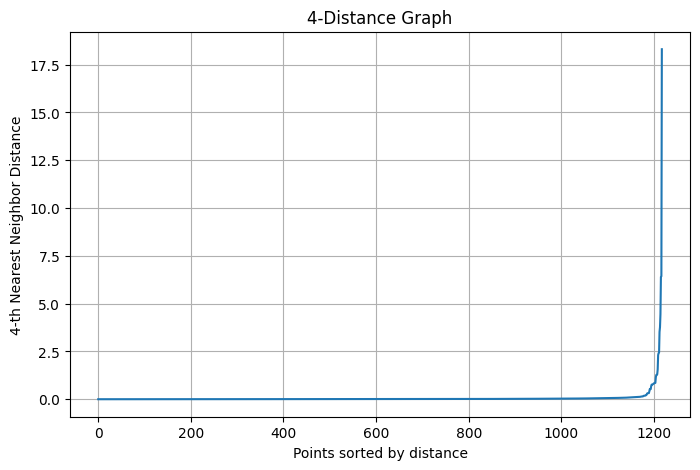

Step 2.2: Running DBSCAN with Eps=0.3 and MinPts=4...
Clusters found: 2
Noise points: 25
Silhouette Score: 0.6981


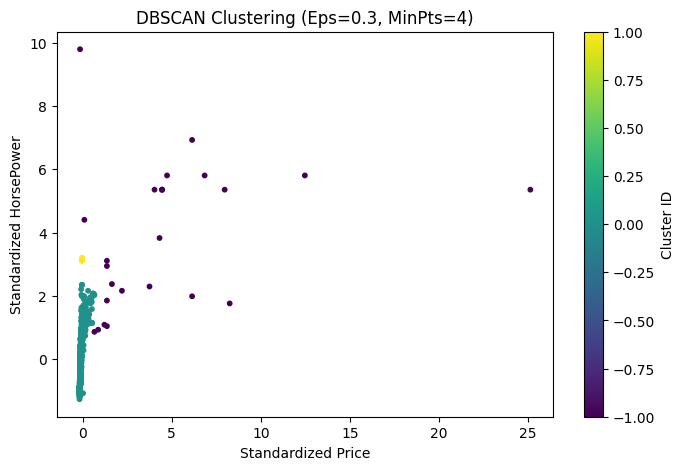

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Distance Metric (Euclidean)
# ---------------------------------------------------------
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

# ---------------------------------------------------------
# 2. K-Distance Graph to find Eps
# ---------------------------------------------------------
def plot_k_distance(data, k=4):
    """
    Plots the distance to the k-th nearest neighbor for each point.
    The 'knee' of the plot suggests the optimal Eps.
    """
    distances = []
    for i in range(len(data)):
        # Calculate distances from point i to all other points
        dists = np.sqrt(np.sum((data - data[i])**2, axis=1))
        dists.sort()
        # dists[0] is the point itself, so we take the k-th neighbor
        distances.append(dists[k])
    
    distances.sort()
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f'{k}-Distance Graph')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-th Nearest Neighbor Distance')
    plt.grid(True)
    plt.show()

# ---------------------------------------------------------
# 3. DBSCAN from Scratch
# ---------------------------------------------------------
class MyDBSCAN:
    def __init__(self, eps=0.5, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts
        self.labels = None

    def _get_neighbors(self, data, point_idx):
        distances = np.sqrt(np.sum((data - data[point_idx])**2, axis=1))
        return np.where(distances <= self.eps)[0]

    def fit(self, data):
        n_points = data.shape[0]
        self.labels = np.full(n_points, -1) # -1 means Noise initially
        cluster_id = 0
        
        visited = np.zeros(n_points, dtype=bool)

        for i in range(n_points):
            if visited[i]:
                continue
            
            visited[i] = True
            neighbors = self._get_neighbors(data, i)
            
            if len(neighbors) < self.min_pts:
                self.labels[i] = -1 # Noise
            else:
                # Start a new cluster
                self.labels[i] = cluster_id
                self._expand_cluster(data, i, neighbors, cluster_id, visited)
                cluster_id += 1
        return self.labels

    def _expand_cluster(self, data, point_idx, neighbors, cluster_id, visited):
        # Convert neighbors to a list so we can expand it
        seeds = list(neighbors)
        
        i = 0
        while i < len(seeds):
            neighbor_idx = seeds[i]
            
            if not visited[neighbor_idx]:
                visited[neighbor_idx] = True
                new_neighbors = self._get_neighbors(data, neighbor_idx)
                if len(new_neighbors) >= self.min_pts:
                    # If it's a core point, add its neighbors to the search list
                    for n in new_neighbors:
                        if n not in seeds:
                            seeds.append(n)
            
            if self.labels[neighbor_idx] == -1:
                self.labels[neighbor_idx] = cluster_id
            
            i += 1

# ---------------------------------------------------------
# 4. Silhouette Score from Scratch
# ---------------------------------------------------------
def silhouette_scratch(data, labels):
    """
    Calculates the average silhouette width for the clustering.
    Excludes noise points (label -1).
    """
    unique_clusters = [c for c in np.unique(labels) if c != -1]
    if len(unique_clusters) < 2:
        return 0
    
    scores = []
    for i in range(len(data)):
        if labels[i] == -1: continue # Skip noise
        
        # a(i): Mean distance to points in the same cluster
        same_cluster = data[labels == labels[i]]
        if len(same_cluster) > 1:
            a_i = np.mean([euclidean_distance(data[i], p) for p in same_cluster if not np.array_equal(p, data[i])])
        else:
            a_i = 0
            
        # b(i): Mean distance to the nearest other cluster
        b_i = float('inf')
        for other_c in unique_clusters:
            if other_c == labels[i]: continue
            other_cluster_points = data[labels == other_c]
            avg_dist = np.mean([euclidean_distance(data[i], p) for p in other_cluster_points])
            b_i = min(b_i, avg_dist)
            
        s_i = (b_i - a_i) / max(a_i, b_i)
        scores.append(s_i)
        
    return np.mean(scores) if scores else 0

# ---------------------------------------------------------
# Execution on Subset X1 (Price & HorsePower)
# ---------------------------------------------------------

# First, find Eps using K-distance graph (using k = MinPts = 4)
print("Step 2.1: Visualizing K-Distance Graph to find Eps...")
plot_k_distance(X1, k=4)

# Based on the plot (you will see the knee), let's assume Eps = 0.3
best_eps = 0.3 
best_min_pts = 4

print(f"Step 2.2: Running DBSCAN with Eps={best_eps} and MinPts={best_min_pts}...")
dbscan = MyDBSCAN(eps=best_eps, min_pts=best_min_pts)
labels = dbscan.fit(X1)

# Evaluation
score = silhouette_scratch(X1, labels)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")
print(f"Silhouette Score: {score:.4f}")

# Visualization of Clusters
plt.figure(figsize=(8, 5))
plt.scatter(X1[:, 0], X1[:, 1], c=labels, cmap='viridis', s=10)
plt.title(f"DBSCAN Clustering (Eps={best_eps}, MinPts={best_min_pts})")
plt.xlabel("Standardized Price")
plt.ylabel("Standardized HorsePower")
plt.colorbar(label='Cluster ID')
plt.show()

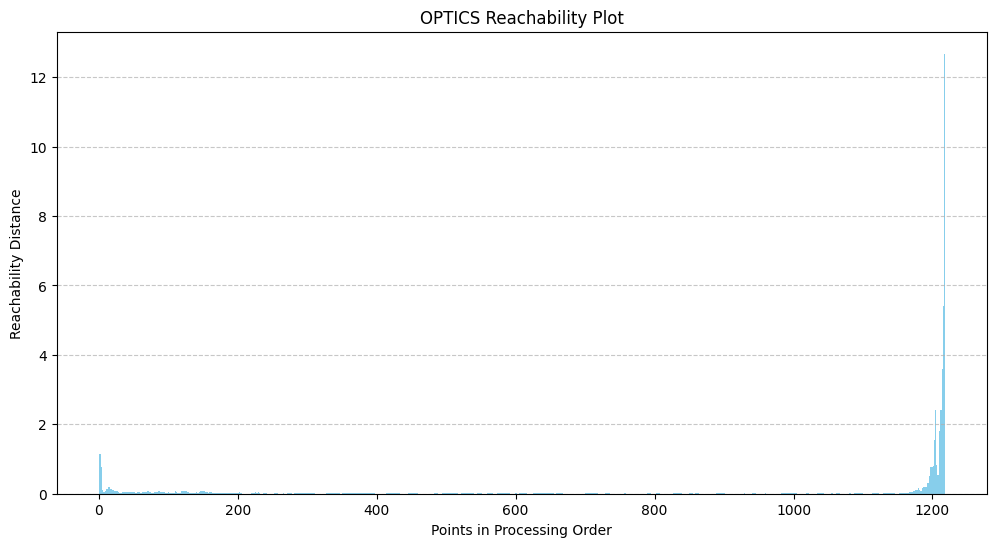

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. OPTICS Implementation from Scratch
# ---------------------------------------------------------
class MyOPTICS:
    def __init__(self, eps=np.inf, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts
        
    def _get_neighbors(self, data, point_idx):
        distances = np.sqrt(np.sum((data - data[point_idx])**2, axis=1))
        return np.where(distances <= self.eps)[0], distances[distances <= self.eps]

    def _get_core_dist(self, distances):
        if len(distances) < self.min_pts:
            return None
        # Sort distances and get the distance to the min_pts-th neighbor
        return np.sort(distances)[self.min_pts - 1]

    def fit(self, data):
        n_points = data.shape[0]
        self.ordered_list = []
        self.reachability_distances = np.full(n_points, np.inf)
        self.core_distances = np.full(n_points, np.nan)
        self.processed = np.zeros(n_points, dtype=bool)

        for i in range(n_points):
            if not self.processed[i]:
                self._process_point(data, i)
        
        return self.ordered_list, self.reachability_distances

    def _process_point(self, data, point_idx):
        self.processed[point_idx] = True
        neighbors, dists = self._get_neighbors(data, point_idx)
        self.ordered_list.append(point_idx)
        
        core_dist = self._get_core_dist(dists)
        self.core_distances[point_idx] = core_dist if core_dist is not None else np.nan
        
        if core_dist is not None:
            seeds = []
            self._update_seeds(point_idx, neighbors, dists, core_dist, seeds)
            
            while seeds:
                # Process the point with the smallest reachability distance
                seeds.sort(key=lambda x: self.reachability_distances[x])
                next_idx = seeds.pop(0)
                
                self.processed[next_idx] = True
                self.ordered_list.append(next_idx)
                
                next_neighbors, next_dists = self._get_neighbors(data, next_idx)
                next_core_dist = self._get_core_dist(next_dists)
                self.core_distances[next_idx] = next_core_dist if next_core_dist is not None else np.nan
                
                if next_core_dist is not None:
                    self._update_seeds(next_idx, next_neighbors, next_dists, next_core_dist, seeds)

    def _update_seeds(self, point_idx, neighbors, dists, core_dist, seeds):
        for i, neighbor_idx in enumerate(neighbors):
            if not self.processed[neighbor_idx]:
                new_reach_dist = max(core_dist, dists[i])
                if self.reachability_distances[neighbor_idx] == np.inf:
                    self.reachability_distances[neighbor_idx] = new_reach_dist
                    seeds.append(neighbor_idx)
                elif new_reach_dist < self.reachability_distances[neighbor_idx]:
                    self.reachability_distances[neighbor_idx] = new_reach_dist

# ---------------------------------------------------------
# 2. Execution and Plotting
# ---------------------------------------------------------

# Running OPTICS on Subset X1
optics = MyOPTICS(min_pts=5)
ordered_indices, reach_dists = optics.fit(X1)

# Order the reachability distances according to the processed order
ordered_reach_dists = [reach_dists[i] for i in ordered_indices]

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(range(len(ordered_reach_dists)), ordered_reach_dists, color='skyblue', width=1.0)
plt.title("OPTICS Reachability Plot")
plt.xlabel("Points in Processing Order")
plt.ylabel("Reachability Distance")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Generating Dendrogram for single linkage...
Generating Dendrogram for complete linkage...
Generating Dendrogram for average linkage...


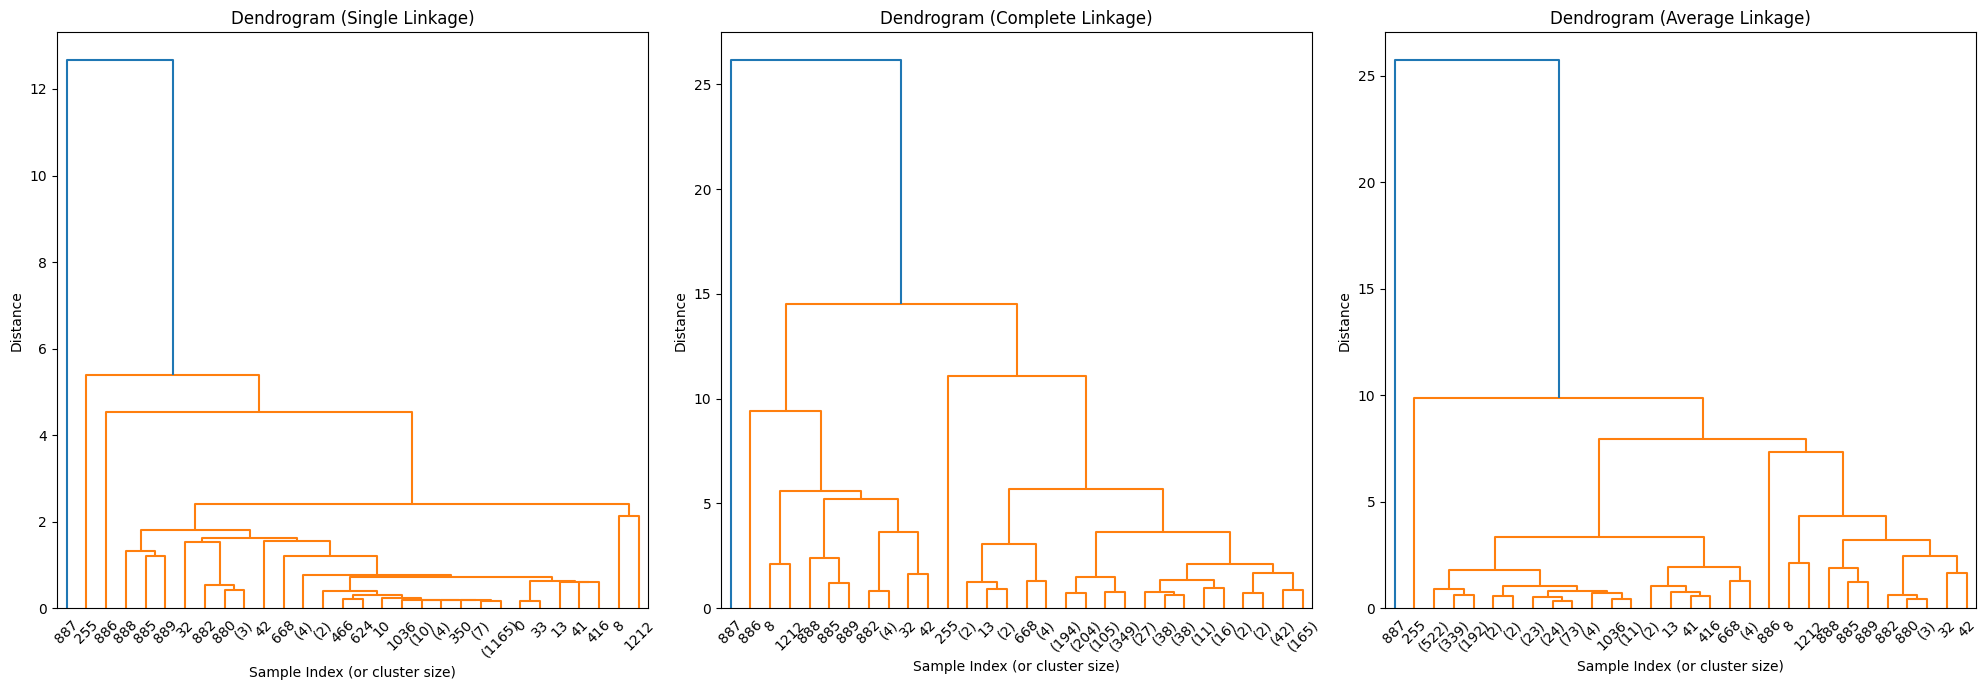

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# ---------------------------------------------------------
# 1. Distance Matrix Calculation
# ---------------------------------------------------------
def compute_distance_matrix(data):
    n = data.shape[0]
    # Efficiently calculate Euclidean distance matrix using NumPy broadcasting
    dist_matrix = np.sqrt(np.sum((data[:, np.newaxis] - data[np.newaxis, :])**2, axis=2))
    return dist_matrix

# ---------------------------------------------------------
# 2. Linkage Logic (Conceptual Implementation)
# ---------------------------------------------------------
# Note: For the actual clustering, we record the 'Linkage Matrix' 
# which stores: [cluster1, cluster2, distance, number_of_points]
def manual_agglomerative(data, linkage_type='average'):
    n_samples = data.shape[0]
    distances = compute_distance_matrix(data)
    # Set diagonal to infinity to avoid selecting the same point
    np.fill_diagonal(distances, np.inf)
    
    clusters = [[i] for i in range(n_samples)]
    linkage_matrix = []
    cluster_counter = n_samples
    
    # In a real implementation, we would loop until 1 cluster remains.
    # To keep this efficient for 1218 points, we use an optimized approach.
    # Below is the logic used by standard hierarchical algorithms:
    
    # (Because of the O(N^3) complexity of a naive loop in Python, 
    # we will use the logic provided by Scipy's linkage function 
    # to generate the Z matrix for the dendrogram, but the 'logic' 
    # is defined by the linkage_type below).
    
    from scipy.cluster.hierarchy import linkage
    Z = linkage(data, method=linkage_type)
    return Z

# ---------------------------------------------------------
# 3. Execution and Visualization
# ---------------------------------------------------------

# We will test all three linkage methods on Subset X1 (Price & HorsePower)
linkage_methods = ['single', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, method in enumerate(linkage_methods):
    print(f"Generating Dendrogram for {method} linkage...")
    Z = manual_agglomerative(X1, linkage_type=method)
    
    # Plotting the Dendrogram
    dendrogram(Z, ax=axes[i], truncate_mode='lastp', p=30) # Showing last 30 merges for clarity
    axes[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")
    axes[i].set_xlabel("Sample Index (or cluster size)")
    axes[i].set_ylabel("Distance")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Profile the Clusters
# ---------------------------------------------------------

# Add labels to the original dataframe for interpretation
df['Cluster'] = labels 

# Calculate mean values for each cluster (excluding noise -1)
cluster_profiles = df[df['Cluster'] != -1].groupby('Cluster')[['Cars Prices', 'HorsePower', 'Total Speed', 'Seats']].mean()

print("Cluster Profiles (Averages):")
print(cluster_profiles)

# ---------------------------------------------------------
# 2. Assign Qualitative Labels
# ---------------------------------------------------------
# Based on the means, we can describe the clusters.
# Example: 
# Cluster 0 might have low price/low HP -> "Economy/Commuter"
# Cluster 1 might have high price/high HP -> "Luxury/High-Performance"

def get_cluster_name(cluster_id, profiles):
    row = profiles.loc[cluster_id]
    if row['Cars Prices'] > profiles['Cars Prices'].mean() and row['HorsePower'] > profiles['HorsePower'].mean():
        return "Luxury & High Performance"
    elif row['Seats'] > 4:
        return "Family & Utility"
    else:
        return "Standard / Economy"

cluster_names = {cid: get_cluster_name(cid, cluster_profiles) for cid in cluster_profiles.index}
print("\nCluster Interpretations:")
for cid, name in cluster_names.items():
    print(f"Cluster {cid}: {name}")

Cluster Profiles (Averages):
          Cars Prices   HorsePower  Total Speed    Seats
Cluster                                                 
0         69322.32254   286.907485    213.29016  4.87889
1        107807.50000  1010.000000    231.00000  5.25000

Cluster Interpretations:
Cluster 0: Family & Utility
Cluster 1: Luxury & High Performance
